In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torch
import torch.nn as nn

# Yolov8 architecture
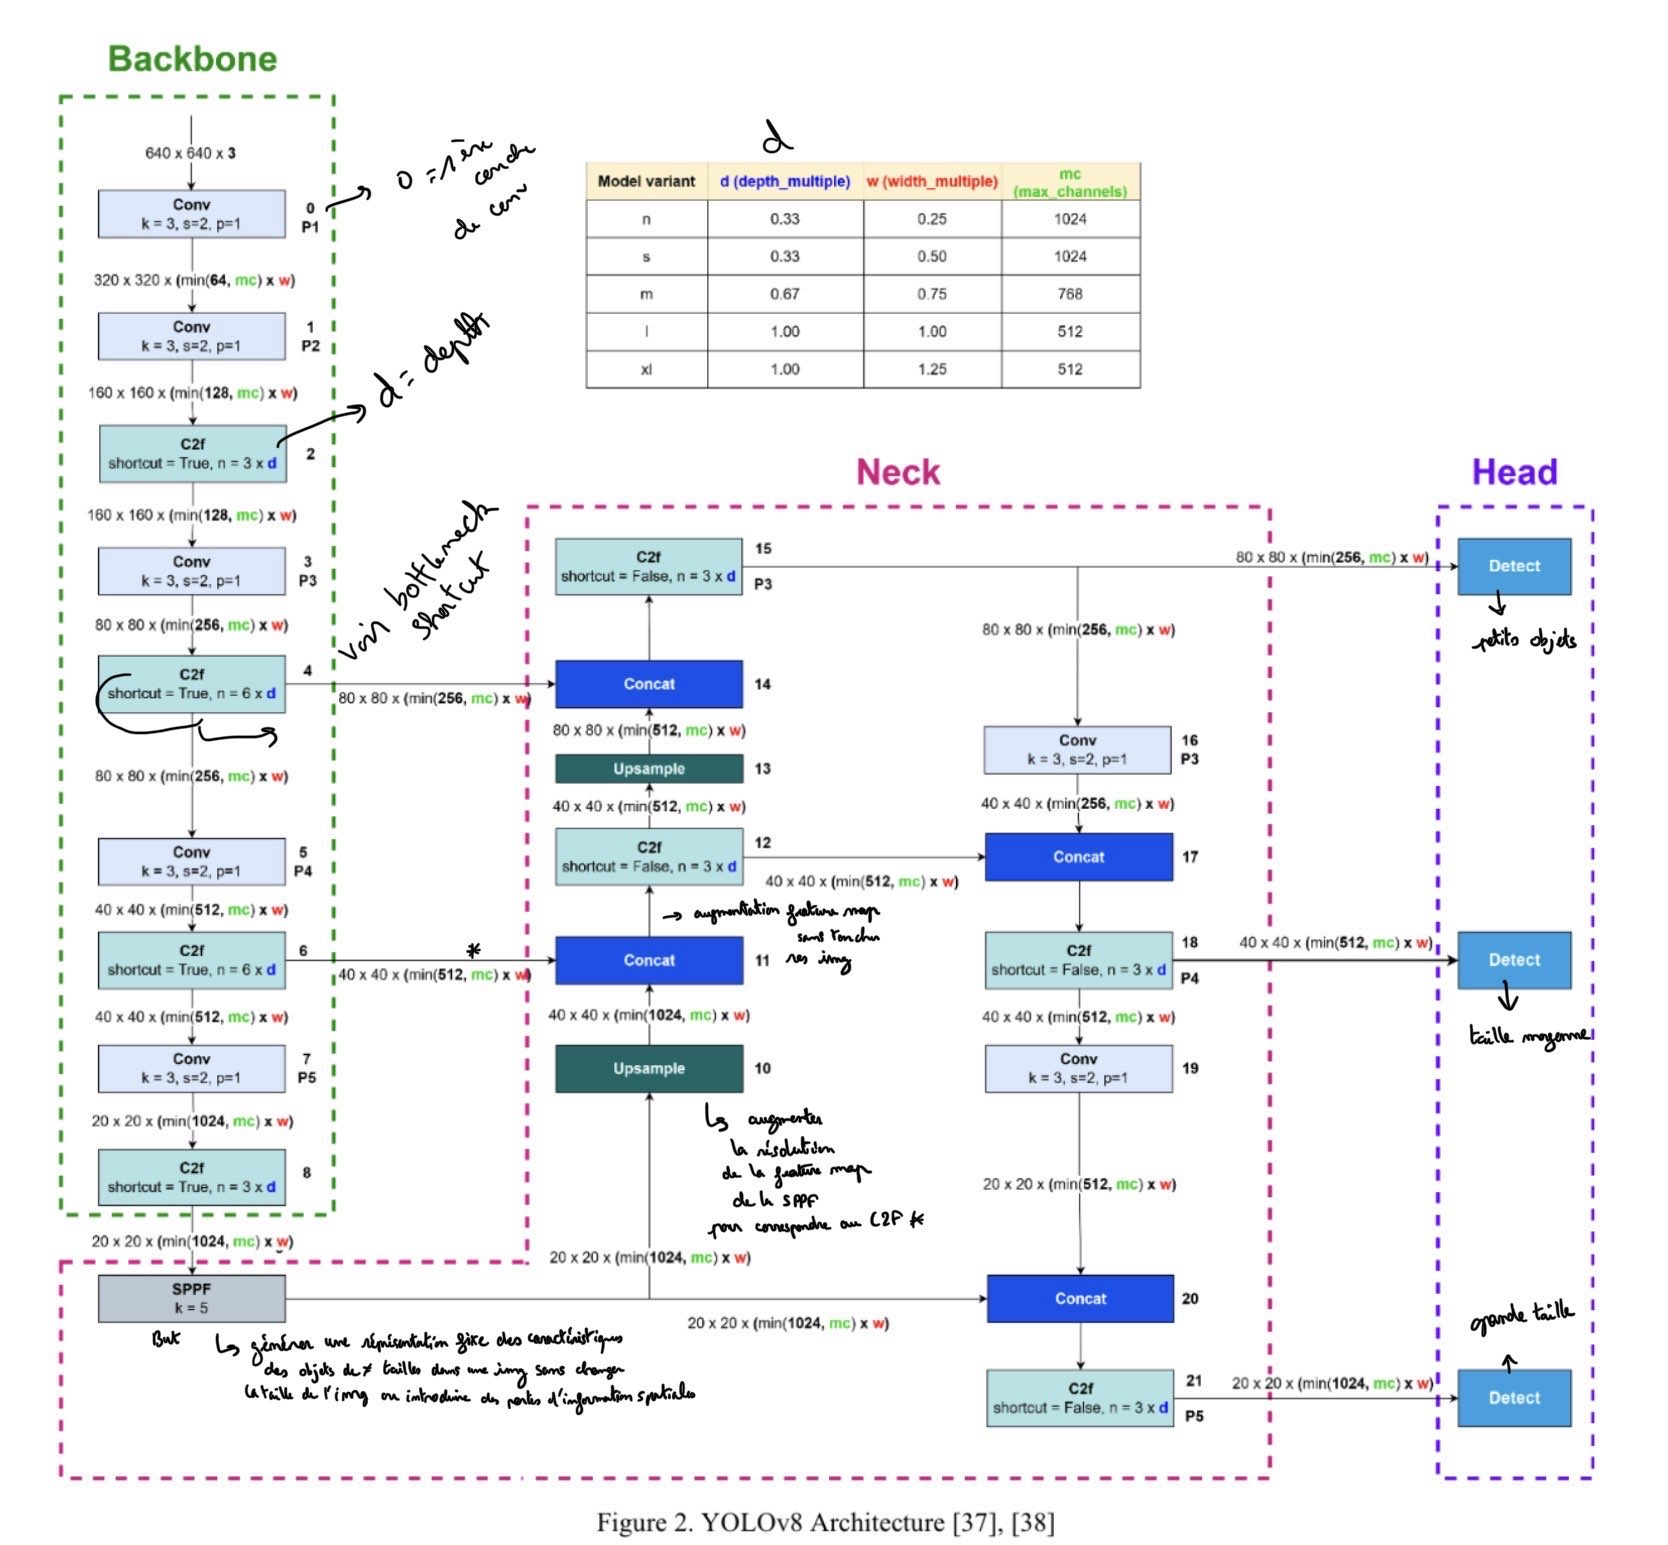

# Couche de convolution
Conv2d + BatchNorm2d + SiLU

In [4]:
class Conv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, groups=1, activation=True):
        super().__init__()
        self.conv=nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False, groups=groups)
        self.bn=nn.BatchNorm2d(out_channels, eps=0.001, momentum = 0.03)
        self.act=nn.SiLU(inplace=True) if activation else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

        
# epsilon = eps

# Bloc C2F (Cross-stage partial bottleneck with 2 convolutions)
Conv + Bottleneck + Conv

Combine les caractéristique de haut niveau avec les information contextuels pour améliorer la précision de la détection.
Avec les connexions residuelles



In [6]:
# Bottleneck : stack de 2 conv avec des connexions résuduelles (True ou  False)
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, shortcut=True):
        super().__init__()
        self.conv1=Conv(in_channels, out_channels, kernel_size=3, stride = 1, padding=1)
        self.conv2=Conv(out_channels, out_channels, kernel_size=3, stride = 1, padding=1)
        self.shortcut=shortcut

    def forward(self, x):
        x_in = x # copy for residual connection
        x = self.conv1(x)
        x = self.conv2(x)
        if self.shortcut :
            x = x + x_in
        return x

class C2F(nn.Module):
    def __init__(self, in_channels, out_channels, num_bottlenecks, shortcut=True):
        super().__init__()
        self.mid_channels = out_channels//2
        self.num_bottlenecks = num_bottlenecks

        self.conv1 = Conv(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

        # Séquence de Bottleneck
        self.m = nn.ModuleList([Bottleneck(self.mid_channels, self.mid_channels) for _ in range(num_bottlenecks)])
        self.conv2 = Conv((num_bottlenecks+2)*out_channels//2, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.conv1(x)
        # Split
        x1, x2 = x[:, :x.shape[1]//2, :, :], x[:, x.shape[1]//2:, :, :] # Moitié des channels de x => après conv sortie = [N, C, H, W] N nombre de batch, C Nb channels, Height, Width  
        # List des sorties x1 et x2
        outputs = [x1, x2] 

        # x1 passe par le bottleneck
        for i in range(self.num_bottlenecks):
            x1 = self.m[i](x1)
            outputs.insert(0,x1)
            
        outputs = torch.cat(outputs, dim = 1) # concaténation [N, 0.5 c_out(num_bottleneck+2),W,H)
        out = self.conv2(outputs)

        return out

# Test de fonctionnement
c2f = C2F(in_channels=64, out_channels = 128, num_bottlenecks=2)
print(f"{sum(p.numel() for p in c2f.parameters())/1e6} millions de paramètres (Bloc C2F)")

dummy_input = torch.rand((1,64,244,244))
dummy_input = c2f(dummy_input)
print("Output shape: ", dummy_input.shape)
            
        
        

0.18944 millions de paramètres (Bloc C2F)
Output shape:  torch.Size([1, 128, 244, 244])


# SPPF
Spatial pyramide pooling fast:
Conv + Maxpool2d + Conv
Trraite les caractéristiques à différentes échelles et les pool en une carte de caractéristique de taille fixe (fixed-size feature map)


In [8]:
class SPPF(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5):
        # Kernel size => taille des maxpool
        super().__init__()
        hidden_channels = in_channels//2
        self.conv1=Conv(in_channels, hidden_channels, kernel_size=1, stride = 1, padding = 0)
        # Concaténer outputs des maxpool et entrer dans conv2
        self.conv2=Conv(4*hidden_channels, out_channels, kernel_size=1, stride = 1, padding = 0)
        # Maxpool à 3 différentes échelles
        self.m= nn.MaxPool2d(kernel_size= kernel_size, stride = 1, padding = kernel_size//2, dilation = 1, ceil_mode=False)

    def forward(self, x):
        x = self.conv1(x)
        # Maxpool
        y1 = self.m(x)
        y2 = self.m(y1)
        y3 = self.m(y2)

        # Concatener
        y = torch.cat([x,y1,y2,y3], dim=1)

        # final conv

        y = self.conv2(y)

        return y

# Test de fonctionnement
sppf = SPPF(in_channels = 128, out_channels=512)
print(f"{sum(p.numel() for p in c2f.parameters())/1e6} millions de paramètres (Bloc SPPF)")


dummy_output = sppf(dummy_input)
print("Output shape: ", dummy_output.shape)
            


0.18944 millions de paramètres (Bloc SPPF)
Output shape:  torch.Size([1, 512, 244, 244])


# Création du backbone
corespond version modifiée de Darknet53

In [10]:
# Différentes versions de YOLO n, s, m, l, xl voir tableau figure 1

def yolo_params(version):
    # return d, w, r en fonctiond de la version
    if version == 'n':
        return 1/3,1/4,2.0
    if version == 's':
        return 1/3,1/2,2.0    
    if version == 'm':
        return 2/3,3/4,1.5
    if version == 'l':
        return 1.0,1.0,1.0
    if version == 'x':
        return 1.0,1.25,1.0

class Backbone(nn.Module):
    def __init__(self, version, in_channels=3, shortcut=True):
        super().__init__()
        d,w,r=yolo_params(version)

        # Chouches de convolution
        self.conv_0=Conv(in_channels, int(64*w), kernel_size=3, stride=2, padding=1)
        self.conv_1=Conv(int(64*w), int(128*w), kernel_size=3, stride=2, padding=1)
        self.conv_3=Conv(int(128*w), int(256*w), kernel_size=3, stride=2, padding=1)
        self.conv_5=Conv(int(256*w), int(512*w), kernel_size=3, stride=2, padding=1)
        self.conv_7=Conv(int(512*w), int(512*w*r), kernel_size=3, stride=2, padding=1)


        # Couches C2F
        self.c2f_2 = C2F(int(128*w), int(128*w), num_bottlenecks=int(3*d), shortcut=True)
        self.c2f_4 = C2F(int(256*w), int(256*w), num_bottlenecks=int(6*d), shortcut=True)
        self.c2f_6 = C2F(int(512*w), int(512*w), num_bottlenecks=int(6*d), shortcut=True)
        self.c2f_8 = C2F(int(512*w*r), int(512*w*r), num_bottlenecks=int(3*d), shortcut=True)

        # SPPF
        self.sppf = SPPF(int(512*w*r),int(512*w*r))

    def forward(self,x):
        x = self.conv_0(x)
        x = self.conv_1(x)
        x = self.c2f_2(x)
        x = self.conv_3(x)
        out1 = self.c2f_4(x) # ici connexion residuelle
        x = self.conv_5(out1)
        out2 = self.c2f_6(x) # //
        x = self.conv_7(out2)
        x = self.c2f_8(x)
        out3 = self.sppf(x)

        return out1, out2, out3

# Test de fonctionnement
print("--- Nano model ---")

backbone_n = Backbone(version='n')
print(f"{sum(p.numel() for p in backbone_n.parameters())/1e6} millions de paramètres")

print("--- Small model ---")

backbone_s = Backbone(version='s')
print(f"{sum(p.numel() for p in backbone_s.parameters())/1e6} millions de paramètres")

print("--- Medium model ---")

backbone_m = Backbone(version='m')
print(f"{sum(p.numel() for p in backbone_m.parameters())/1e6} millions de paramètres")

print("--- Large model ---")

backbone_l = Backbone(version='l')
print(f"{sum(p.numel() for p in backbone_l.parameters())/1e6} millions de paramètres")

print("--- Extra Large model ---")

backbone_x = Backbone(version='x')
print(f"{sum(p.numel() for p in backbone_x.parameters())/1e6} millions de paramètres")


# Test dummy variable
x = torch.rand((1,3,640,640))
out1, out2, out3 = backbone_n(x)
print(out1.shape)
print(out2.shape)
print(out3.shape)      

--- Nano model ---
1.272656 millions de paramètres
--- Small model ---
5.079712 millions de paramètres
--- Medium model ---
11.855856 millions de paramètres
--- Large model ---
19.808576 millions de paramètres
--- Extra Large model ---
30.94312 millions de paramètres
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


# Neck
constitué de bloc de upsample et C2F  
**Updample** = interpolation nearest-neighbor avec un scale_factor = 2. => Pas de paramètres entrainables

In [12]:
class Upsample(nn.Module):
    def __init__(self, scale_factor=2, mode='nearest'):
        super().__init__()
        self.scale_factor = scale_factor
        self.mode = mode

    def forward(self,x):
        return nn.functional.interpolate(x, scale_factor = self.scale_factor, mode = self.mode)

In [13]:
class Neck(nn.Module):
    def __init__(self, version):
        super().__init__()
        d,w,r = yolo_params(version)
        self.up = Upsample() # pas de paramètres entrainables
        self.c2f_1 = C2F(in_channels=int(512*w*(1+r)), out_channels = int(512*w), num_bottlenecks = int(3*d), shortcut=False)
        self.c2f_2 = C2F(in_channels=int(768*w), out_channels = int(256*w), num_bottlenecks = int(3*d), shortcut=False)
        self.c2f_3 = C2F(in_channels=int(768*w), out_channels = int(512*w), num_bottlenecks = int(3*d), shortcut=False)
        self.c2f_4 = C2F(in_channels=int(512*w*(1+r)), out_channels = int(512*w*r), num_bottlenecks = int(3*d), shortcut=False)

        self.conv_1 = Conv(in_channels = int(256*w), out_channels= int(256*w), kernel_size = 3, stride = 2, padding = 1)
        self.conv_2 = Conv(in_channels = int(512*w), out_channels= int(512*w), kernel_size = 3, stride = 2, padding = 1)

    def forward(self, x_res_1, x_res_2, x):
        # x_res les connexions residuelles du backbone voir architecturee
        res_1 = x # Pour prochaine connexion residuelle

        x=self.up(x)
        x=torch.cat([x, x_res_2], dim=1)

        res_2 = self.c2f_1(x) # Prochaine connexion res
        x = self.up(res_2)
        x = torch.cat([x, x_res_1], dim=1)
        
        out_1 = self.c2f_2(x)

        x = self.conv_1(out_1)
        x = torch.cat([x, res_2], dim = 1)
        out_2 = self.c2f_3(x)

        x = self.conv_2(out_2)


        x = torch.cat([x, res_1], dim = 1)
        out_3 = self.c2f_4(x)

        return out_1, out_2, out_3

# Test de fonctionnement
neck = Neck(version = 'n')
print(f"{sum(p.numel() for p in neck.parameters())/1e6} millions de paramètres")

x = torch.rand((1,3,640,640))
out1, out2, out3 = Backbone(version='n')(x)
out_1, out_2, out_3 = neck(out1, out2, out3)
print(out_1.shape)
print(out_2.shape)
print(out_3.shape)
        

0.98688 millions de paramètres
torch.Size([1, 64, 80, 80])
torch.Size([1, 128, 40, 40])
torch.Size([1, 256, 20, 20])


# Head
3 Modules :
- Coordonnées des bounding box
- score de classification (proba que l'objet appartienne à une classe)
- DFL Distribution Focal Loss

**DFL** considère les coordonnées des boîtes englobantes comme des distributions de probabilité.(Au lieu de prédire directement la coordonnée, le modèle prédit une distribution de proba)
Lors de l'inférence, on échantillone depuis la distribution pour obtenir des coordonnées rafinées (x,y,w,h).

Exemple :
On veut prédire la coordonnée x dans un intervalle normalisé [0,1] :
1. DFL découpe en 16 morceaux l'interval => 1 bin = 1/16 = 0.0625
2. Sortie du modèle pas 1 valeur mais 16 avec chaque valeur = probabilité que la coordonnée soit dans le bin [0,0,...,9/10,1/10]
3. La prédiction n'est pas la valeur max mais une valeur moyenne pondérée, on combine la valeur des bin avec leur position x = 9/10 * 15/16 + 1/10 * 16/16 = 0.94375



In [15]:
# DFL
class DFL(nn.Module):
    def __init__(self,ch=16): # 16 bins
        super().__init__()
        
        self.ch=ch
        
        self.conv=nn.Conv2d(in_channels=ch,out_channels=1,kernel_size=1,bias=False).requires_grad_(False) # on initialise conv avec [0,...,ch-1] => 16 poids 0-15
        # on l'utilise qu'en inférence donc inutile de calculer les gradients
        # ressort 1 valeur 
        
        # Initialisation des poids :
        x=torch.arange(ch,dtype=torch.float).view(1,ch,1,1) # création du vecteur des bins pour reshape en tenseur [1,16,1,1] 
        # car conv2d input type [out_ch,in_ch, kernel_h, k_w]
        self.conv.weight.data[:]=torch.nn.Parameter(x) # DFL a que les bins en params, poids le la conv de shape [1,16,1,1]
        # .data => accés direct aux données [:] => tout le tenseur

        # Chaque bin correspond à une position puis on fait une moyenne pondérée
        # La convolution fait le calcul d'une espérence mathématique ??
    
    def forward(self,x):
        # x doit avoir num_channels = 4*ch : x = [bs,4*ch,c] car 4 coordonnées et chaque coordonnées à 16 bins
        # b = batch, c = 64, a = nb de position (pixel ou anchors
        b,c,a=x.shape                           # c=4*ch
        x=x.view(b,4,self.ch,a).transpose(1,2)  # reshape en [bs,ch,4,a] on ajoute les 4 coordonnées (on sépare les coordonnées x,y,h,w qui ont 16 bins)
        # on spépare le c = 64 en 4 * 16 puis transpose
        # On applique softmax sur la dimension des ch pour avoir une distribution de proba
        x=x.softmax(1)                          # [b,ch,4,a] => les 16 bins sur la position 1 où on applique softmax pour obtenir probas
        x=self.conv(x)                          # [b,1,4,a] conv 1*1
        return x.view(b,4,a)                    # reshape [b,4,a] pour enlever la dimension inutile

# Résumé :
# Le modèle prédit 16 valeurs par coordonnée
# On applique softmax => probabilités
# On fait une moyenne pondérée avec [0..15]
# On obtient une coordonnée précise

# Test de fonctionnement 

dummy_input=torch.rand((1,64,128))

dfl=DFL()
print(f"{sum(p.numel() for p in dfl.parameters())} parameters")

dummy_output=dfl(dummy_input)
print(dummy_output.shape)

print(dfl)

16 parameters
torch.Size([1, 4, 128])
DFL(
  (conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1), bias=False)
)


In [16]:
class Head(nn.Module): # Produit les bbox, les classes et applique dfl en inférence
    def __init__(self,version,ch=16,num_classes=80):

        super().__init__()
        self.ch=ch                          # 16 bins
        self.coordinates=self.ch*4          # nombre de coordonnées x,y,h,w = 4 * 16 = 64
        self.nc=num_classes                 # 80 classes pour COCO
        self.no=self.coordinates+self.nc    # nombre de sortie par pixel/anchors = 64+80=144

        self.stride=torch.zeros(3)          # 3 niveaux de détection/résolution ex = [8,16,32] => 8 => 8 pixels de l'image => 1 sortie
        # Pour les blocs de détection objet petit, objet moyen et objet large
        
        d,w,r=yolo_params(version=version)
        
        # Pour les bbox => 3 bloc un par niveau de résolution, conv => conv  => conv 1*1
        # Blocs de détections :
        #Bbox 
        self.box=nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w*r),self.coordinates,kernel_size=3,stride=1,padding=1),
                          Conv(self.coordinates,self.coordinates,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.coordinates,self.coordinates,kernel_size=1,stride=1))
        ]) # En sortie on a [bs, 64, h, w]

        # Pour la classification
        self.cls=nn.ModuleList([
            nn.Sequential(Conv(int(256*w),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1)),

            nn.Sequential(Conv(int(512*w*r),self.nc,kernel_size=3,stride=1,padding=1),
                          Conv(self.nc,self.nc,kernel_size=3,stride=1,padding=1),
                          nn.Conv2d(self.nc,self.nc,kernel_size=1,stride=1))
        ])

        # dfl
        self.dfl=DFL()

    def forward(self,x):
        # x = output of Neck = list of 3 tensors with different resolution and different channel dim
        #     x[0]=[bs, ch0, w0, h0], x[1]=[bs, ch1, w1, h1], x[2]=[bs,ch2, w2, h2] 

        for i in range(len(self.box)):       # pour chaque niveau de feature map (3 =!)
            box=self.box[i](x[i])            # [bs,num_coordinates,w,h]
            cls=self.cls[i](x[i])            # [bs,num_classes,w,h]
            x[i]=torch.cat((box,cls),dim=1)  # [bs,num_coordinates+num_classes,w,h]

        # En entrainement pas de sortie DFL
        if self.training:
            return x                         # [3,bs,num_coordinates+num_classes,w,h]
        
        # Lors de l'inference, dfl produit des coordonnées refined bounding box
        anchors, strides = (i.transpose(0, 1) for i in self.make_anchors(x, self.stride)) # créationn des anchors

        # concatenation des predictions de toute les couches de prédiciton
        x = torch.cat([i.view(x[0].shape[0], self.no, -1) for i in x], dim=2) #[bs, 4*self.ch + self.nc, sum_i(h[i]w[i])]
        
        # On sépare les prédicitons des bbox et classes
        #           box=[bs,4×self.ch,sum_i(h[i]w[i])]
        #           cls=[bs,self.nc,sum_i(h[i]w[i])]
        box, cls = x.split(split_size=(4 * self.ch, self.nc), dim=1)


        a, b = self.dfl(box).chunk(2, 1)  # a=b=[bs,2×self.ch,sum_i(h[i]w[i])] passage DFL
        a = anchors.unsqueeze(0) - a # ancors = centre et a distance haut gazuche, b distance bas droite
        b = anchors.unsqueeze(0) + b
        box = torch.cat(tensors=((a + b) / 2, b - a), dim=1) # centre = (a+b)/2 et taille = b-a
        
        return torch.cat(tensors=(box * strides, cls.sigmoid()), dim=1) # box * stride pour remettre les coordonées à l'échelle de l'image
        # activation sigmoidequi transforme les logits en proba


    def make_anchors(self, x, strides, offset=0.5):
        # x= list des features maps: x=[x[0],...,x[N-1]], dans notre cas N= num_detection_heads=3
        # chaque x de shape [bs,ch,w,h]
        # chaque feature map x[i] donne output[i] = w*h anchor coordinates + w*h stride values
        
        # strides = Liste des valeurs de stride qui indique comment est réduit la résolution spatial des features map par rapport à l'image réelle

        assert x is not None
        anchor_tensor, stride_tensor = [], []
        dtype, device = x[0].dtype, x[0].device
        for i, stride in enumerate(strides):
            _, _, h, w = x[i].shape
            sx = torch.arange(end=w, device=device, dtype=dtype) + offset  # x coordonnées centres des anchors
            sy = torch.arange(end=h, device=device, dtype=dtype) + offset  # y 
            sy, sx = torch.meshgrid(sy, sx)   # création grille 2d avec tout les centres des anchors 
            anchor_tensor.append(torch.stack((sx, sy), -1).view(-1, 2)) # on combine x et y puis flatten => chaque ligne = un anchor
            stride_tensor.append(torch.full((h * w, 1), stride, dtype=dtype, device=device))
        return torch.cat(anchor_tensor), torch.cat(stride_tensor)

In [17]:
detect=Head(version='n')
print(f"{sum(p.numel() for p in detect.parameters())/1e6} million parameters")

# out_1,out_2,out_3 sont les sorties du neck
output=detect([out_1,out_2,out_3])
print(output[0].shape)
print(output[1].shape)
print(output[2].shape)

print(detect)

0.897664 million parameters
torch.Size([1, 144, 80, 80])
torch.Size([1, 144, 40, 40])
torch.Size([1, 144, 20, 20])
Head(
  (box): ModuleList(
    (0): Sequential(
      (0): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): Sequential(
      (0): Conv(
        (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

# YOLO
On assemble toute les parties de l'architecture

In [19]:


class MyYolo(nn.Module):
    def __init__(self,version):
        super().__init__()
        self.backbone=Backbone(version=version)
        self.neck=Neck(version=version)
        self.head=Head(version=version)

    def forward(self,x):
        x=self.backbone(x)              # return out1,out2,out3
        x=self.neck(x[0],x[1],x[2])     # return out_1, out_2,out_3
        return self.head(list(x))
    
model=MyYolo(version='n')
print(f"{sum(p.numel() for p in model.parameters())/1e6} million parameters")
print(model)

3.1572 million parameters
MyYolo(
  (backbone): Backbone(
    (conv_0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_3): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (conv_5): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (

In [20]:
import os
print(os.getcwd())

C:\Users\mathi\yolov8_project


In [21]:
import sys
sys.path.append(r"C:/Users/mathi/yolov8_project/utils")

# Dataset et entraînement du modèle 

In [48]:
import yaml
from utils.dataset import *
from torch.utils import data

# get all file names
data_dir= 'COCO'
filenames_train = []
with open(f'{data_dir}/train2017.txt') as reader:
    for filename in reader.readlines():
        filename = os.path.basename(filename.rstrip())
        filenames_train.append(f'{data_dir}/images/train2017/' + filename)

# input_size for the model
input_size=640

# get params from yaml file
with open('utils/args.yaml', errors='ignore') as f:
        params = yaml.safe_load(f)

train_data=Dataset(filenames_train,input_size,params,augment=True)
train_loader = data.DataLoader(train_data, batch_size=64, num_workers=0, pin_memory=True, collate_fn=Dataset.collate_fn)
print(f"Train_loader : {len(train_loader)} batches")

FileNotFoundError: [Errno 2] No such file or directory: 'COCO/train2017.txt'

In [46]:
batch=next(iter(train_loader))
print("All keys in batch      : ", batch[1].keys())
print(f"Input batch shape      : ", batch[0].shape)
print(f"Classification scores  : {batch[1]['cls'].shape}")
print(f"Box coordinates        : {batch[1]['box'].shape}")
print(f"Index identifier (which score belongs to which image): {batch[1]['idx'].shape}")

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
from utils import util
torch.manual_seed(1337)

# model, loss et optimizer
model=MyYolo(version='n')
print(f"{sum(p.numel() for p in model.parameters())/1e6} millions de parametres")

criterion=util.ComputeLoss(model, params)
optimizer=torch.optim.AdamW(model.parameters(), lr=0.5)

num_epochs=5

imgs,targets=batch[0],batch[1]
imgs=imgs.float()
model.train()
for epoch in range(num_epochs):
    outputs=model(imgs)
    loss=sum(criterion(outputs,targets)) # cls_loss+box_loss+dfl_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch : {epoch} | loss : {loss.item()}")